## **Modelagem: Random Forest**

Neste notebook vamos construir e avaliar um modelo de classificação Random Forest para prever os funcionários que pedirão demissão voluntária.

O Random Forest (RF) será nosso segundo modelo e vamos compará-lo com a regressão logística, nosso baseline. 

O processo de modelagem seguirá as seguintes etapas:

- **Pipeline de transformações**: vamos definir um pipeline de transformadores para preparar nossos dados.

- **Tuning do modelo**: vamos usar 10 dobras de validação cruzada para treinar e validar 150 modelos diferentes, com hiperparâmetros aleatóriamente escolhido no espaço de parâmetros possíveis. Vamos optar pelo modelo que melhor equilibra `recall` e `roc_auc`. 

- **Treinamento do melhor modelo**: vamos selecionar os hiperparâmetros do melhor modelo e treiná-lo no conjunto completo de treinamento

- **Métricas de avaliação no treinamento**: vamos avaliar a acurácia, curva ROC, precisão, recall e f1-score no conjunto de treinamento.

---

Obs: A análise da interpretabiliade será feita com o modelo final escolhido, bem como o teste no conjunto de testes. 

In [1]:
### libs ###
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

### dados ###
X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv")

In [2]:
#Random Forest

In [3]:
# 1) Grupos de variáveis
tipos_variaveis1 = {
    "binarias": [
        "catl_sexo","catl_doenca_cronica","catl_animais","catl_homeopatia",
        "catl_internacao","catl_quimicos","catl_ruidos","catl_sol",
        "catl_material_biologico","catl_plano_saude","catl_medicamentos",
        "catl_plantas_medicinais","catl_deixar_atividades","catl_servico_saude",
        "catl_recebeu_atendimento","catl_lixo","catl_poeira_mineral",
        "catl_plano_consultas","catl_plano_exames","catl_plano_internacoes",
        "catl_crise_asma","catl_remedio_asma","catl_aerossol_asma",
        "catl_cigarro","catl_pagou_remedio","catl_domicilio_cadastrado"
    ],

    "numericas": [
        "num_idade","catl_cachoros","catl_gatos",
        "num_idade_diagnostico","num_consultas"
    ],

    "ordinais": [
        "ord_saude","ord_limita_asma","ord_agente_saude",
        "ord_nivel_plano","ord_remedio_semana","ord_remedio_sus",
        "ord_farmacia_popular"
    ],

    "categoricas": [
        "catl_cor_raca","catl_tipo_de_area","catl_tipo_de_domicilio",
        "cath_material_parede","cath_fonte_de_agua",
        "catl_destino_do_lixo","catl_atividade","cath_estado_agua",
        "cath_local_atendimento"
    ],

    "alta_cardinalidade": [
        "cath_destino_do_esgoto","cath_trabalho"
    ]
}


## **Transformações**

Um conjunto de transformações foi definido de acordo com o tipo de variável:

- **Numéricas:** padronizadas por escore Z -> maior estabilidade numérica. Embora seja menos necessário no RF, costuma ajudar. 

- **Ordinais:** codificação ordinal -> respeita a interpretação de ordem

- **Binárias** codificação OneHot -> similar à dummy, mas não remove uma das categorias.

- **Politômicas:** codificação pelo alvo -> evita que o número de colunas se torne muito grande

Como não haviam *missings*, um imputador não era necessário, mas, para fins de exemplo, o imputador KNN foi acrescentado ao Pipeline. 

In [6]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, TargetEncoder
from sklearn.pipeline import Pipeline

# OneHot compatível (usa esparso quando fizer sentido)
ohe_kwargs = dict(handle_unknown="ignore", dtype=np.float32)
try:
    OHE_BIN = OneHotEncoder(drop="if_binary", sparse_output=True, **ohe_kwargs)
    OHE_CAT = OneHotEncoder(sparse_output=True, **ohe_kwargs)
except TypeError:  # sklearn < 1.2
    OHE_BIN = OneHotEncoder(drop="if_binary", sparse=True, **ohe_kwargs)
    OHE_CAT = OneHotEncoder(sparse=True, **ohe_kwargs)

# ---- Pipelines ----
num_pipe = Pipeline([
    ("imputer", KNNImputer(n_neighbors=10)),
    ("scaler", StandardScaler())
])

ord_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

bin_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OHE_BIN)
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OHE_CAT)
])

high_card_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("target", TargetEncoder())
])

# ---- Pré-processamento ----
pre = ColumnTransformer(
    transformers=[
        ("numeric",     num_pipe, tipos_variaveis1["numericas"]),
        ("ordinal",     ord_pipe, tipos_variaveis1["ordinais"]),
        ("binary",      bin_pipe, tipos_variaveis1["binarias"]),
        ("categorical", cat_pipe, tipos_variaveis1["categoricas"]),
        ("high_card",   high_card_pipe, tipos_variaveis1["alta_cardinalidade"]),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)


## **Modelo**

Um classificador `RandomForest` foi instanciado.

In [7]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=1500)

In [8]:
# 1) Pipeline: pré-processamento + RandomForest
pipeline = Pipeline([
    ("pre", pre),
    ("clf", RandomForestClassifier(
        n_estimators=1500,
        random_state=42,
        n_jobs=-1
    ))
])


In [10]:
from scipy.stats import randint

param_distributions = {
    'clf__max_depth': [3, 5, 7,10, None],
    'clf__min_samples_split': randint(5, 21),
    'clf__min_samples_leaf': randint(3, 16),
    'clf__max_features': ['sqrt', 'log2', 0.2, 0.3, 0.4, 0.5],
    'clf__max_samples': [0.5, 0.6 ,0.8, None],
    'clf__criterion': ['gini', 'entropy'],
    'clf__class_weight': ['balanced', 'balanced_subsample', None]
}

In [11]:
# randomized search cv
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=pipeline,                        # nosso pipeline
    param_distributions=param_distributions,   # grade de hiperparâmetros
    n_iter=50,                                # número máximo de modelos a tentar
    cv=5,                                     # 10 dobras de StratifiedKFold
    random_state=42,
    n_jobs=-1,                                 # usar todos os núcleos do processador
    verbose=3,                                 # resultados mais informativos do processo
    scoring=["roc_auc", "precision", "recall"],           # computar acurácia e roc_auc
    refit="roc_auc"                            # ajustar melhor modelo baseado na roc_auc
)
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


C:\Users\T-Gamer\anaconda3\envs\atividade2\lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\T-Gamer\anaconda3\envs\atividade2\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('pre',
                                              ColumnTransformer(transformers=[('numeric',
                                                                               Pipeline(steps=[('imputer',
                                                                                                KNNImputer(n_neighbors=10)),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['num_idade',
                                                                                'catl_cachoros',
                                                                                'catl_gatos',
                                                                                'num_idade_diagnostico',
                                                                                'num_consultas']),
                                                                              ('ordinal',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('...
                                                              0.2, 0.3, 0.4,
                                                              0.5],
                                        'clf__max_samples': [0.5, 0.6, 0.8,
                                                             None],
                                        'clf__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001F5DDACCBE0>,
                                        'clf__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001F5D9D55E50>},
                   random_state=42, refit='roc_auc',
                   scoring=['roc_auc', 'precision', 'recall'], verbose=3)

In [12]:
# salvar objeto randomized search completo
joblib.dump(random_search, 'randomforest_random_search.joblib')

['randomforest_random_search.joblib']

In [13]:
# carregar objeto randomized search completo
random_search = joblib.load('randomforest_random_search.joblib')

## **Avaliação dos modelos treinados**

Vamos analisar os resultados obtidos para os modelos a partir dos valores de `accuracy`, `roc_auc` e `recall`. Escolheremos o modelo com melhor `roc_auc` e `recall`. 

In [14]:
# ver resultados
results_vars = [
    "mean_test_roc_auc",
    "mean_test_precision",   
    "mean_test_recall",
    "rank_test_roc_auc",
    "rank_test_precision",   
    "rank_test_recall"
]

resultados_search = pd.DataFrame(random_search.cv_results_)

resultados_search[results_vars]


,mean_test_roc_auc,mean_test_precision,mean_test_recall,rank_test_roc_auc,rank_test_precision,rank_test_recall
0,0.977191,0.992444,0.615005,8,17,36
1,0.962093,0.998950,0.555966,20,9,39
2,0.963053,0.999377,0.452986,19,8,44
3,0.975347,0.519655,0.875493,11,35,3
4,0.959833,0.514165,0.740072,24,36,19
5,0.973820,0.998181,0.630955,12,14,35
6,0.945178,1.000000,0.379690,39,1,45
7,0.958868,0.384735,0.781763,25,49,13
8,0.916119,0.419279,0.662859,50,45,33
9,0.976659,0.995305,0.651381,9,16,34


Para encontrar o modelo com melhor `roc_auc` e `recall`, desconsiderando o tempo de treinamento, vamos usar a seguinte equação:

$$
\argmin_{i=0}^{149} (rank_{AUC}^{(i)} + rank_{recall}^{(i)})
$$

In [15]:
# soma dos ranks
resultados_search["score"] = resultados_search.rank_test_roc_auc + resultados_search.rank_test_recall

# minimizar a soma dos ranks
resultados_search.sort_values(by="score")[results_vars]

,mean_test_roc_auc,mean_test_precision,mean_test_recall,rank_test_roc_auc,rank_test_precision,rank_test_recall
45,0.978560,0.616313,0.887245,4,26,1
12,0.978522,0.615674,0.886125,5,27,2
15,0.985024,0.856243,0.856468,1,21,6
48,0.983797,0.889606,0.830450,2,19,9
3,0.975347,0.519655,0.875493,11,35,3
42,0.975442,0.524386,0.875213,10,34,4
37,0.973332,0.488910,0.872693,13,39,5
19,0.977920,0.823237,0.787920,6,22,12
23,0.977885,0.880286,0.754344,7,20,15
38,0.963963,0.385769,0.848915,18,48,7


O modelo "13" foi o melhor!

In [16]:
# parâmetros do modelo escolhido
best_params = resultados_search["params"][45]

best_params

{'clf__class_weight': 'balanced_subsample',
 'clf__criterion': 'entropy',
 'clf__max_depth': 10,
 'clf__max_features': 0.5,
 'clf__max_samples': 0.8,
 'clf__min_samples_leaf': 11,
 'clf__min_samples_split': 7}

In [17]:
# tempo de treinamento e pontuação do modelo escolhido
resultados_search[["mean_fit_time", "mean_score_time"]].iloc[45,]

mean_fit_time      554.216601
mean_score_time    208.511799
Name: 45, dtype: float64

In [18]:
# definir parâmetros para o pipeline
pipeline.set_params(**best_params)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=10)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['num_idade', 'catl_cachoros',
                                                   'catl_gatos',
                                                   'num_idade_diagnostico',
                                                   'num_consultas']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('enc',
                                                                   OrdinalEncoder(handle_unknown...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('target',
                                                                   TargetEncoder())]),
                                                  ['cath_destino_do_esgoto',
                                                   'cath_trabalho'])],
                                   verbose_feature_names_out=False)),
                ('clf',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        criterion='entropy', max_depth=10,
                                        max_features=0.5, max_samples=0.8,
                                        min_samples_leaf=11,
                                        min_samples_split=7, n_estimators=1500,
                                        n_jobs=-1, random_state=42))])

In [19]:
pipeline.fit(X_train, y_train)

C:\Users\T-Gamer\anaconda3\envs\atividade2\lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\T-Gamer\anaconda3\envs\atividade2\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=10)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['num_idade', 'catl_cachoros',
                                                   'catl_gatos',
                                                   'num_idade_diagnostico',
                                                   'num_consultas']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('enc',
                                                                   OrdinalEncoder(handle_unknown...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('target',
                                                                   TargetEncoder())]),
                                                  ['cath_destino_do_esgoto',
                                                   'cath_trabalho'])],
                                   verbose_feature_names_out=False)),
                ('clf',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        criterion='entropy', max_depth=10,
                                        max_features=0.5, max_samples=0.8,
                                        min_samples_leaf=11,
                                        min_samples_split=7, n_estimators=1500,
                                        n_jobs=-1, random_state=42))])

## **Avaliação do modelo no conjunto de treinamento**

Vamos avaliar o modelo no conjunto de treinamento

In [20]:
# classificador baseline aleatório
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="stratified", random_state=42)

dummy.fit(X_train, y_train)

DummyClassifier(random_state=42, strategy='stratified')

In [21]:
# acurácia
from sklearn.metrics import accuracy_score

acc_dummy = accuracy_score(y_train, dummy.predict(X_train))
acc_modelo = accuracy_score(y_train, pipeline.predict(X_train))

print(f"O modelo dummy obteve acurácia de {acc_dummy:.1%}")
print(f"A modelo RF obteve acurácia de {acc_modelo:.1%}")
print(f"Isso significa que o RF trouxe um aumento de acurácia de {acc_modelo - acc_dummy:.1%}")

O modelo dummy obteve acurácia de 90.8%
A modelo RF obteve acurácia de 96.8%
Isso significa que o RF trouxe um aumento de acurácia de 6.0%


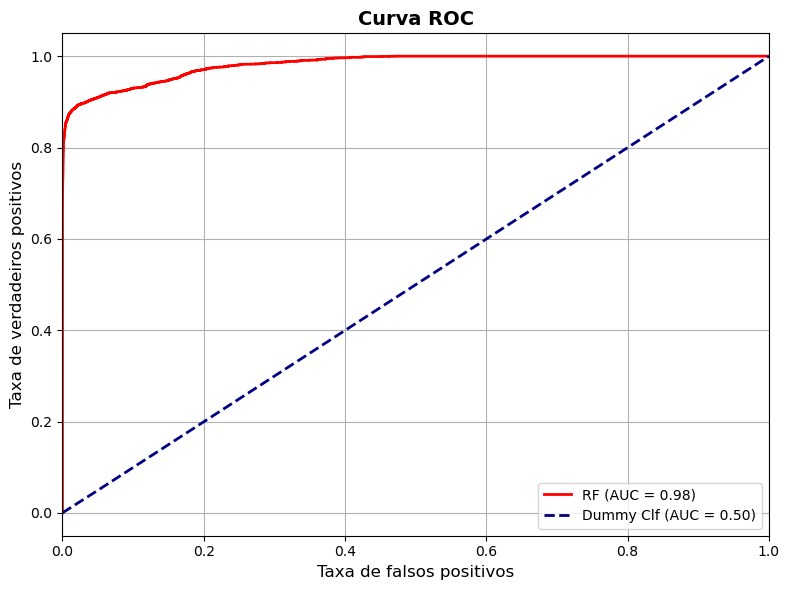

In [22]:
# curva ROC
from sklearn.metrics import roc_curve, auc
fpr_d, tpr_d, thresholds_d = roc_curve(y_train, dummy.predict_proba(X_train)[:, 1])
fpr, tpr, thresholds = roc_curve(y_train, pipeline.predict_proba(X_train)[:, 1])

# gráfico
plt.figure(figsize=(8, 6))

# Plot da curva ROC do seu Pipeline
plt.plot(fpr, tpr,
         color='red', 
         linewidth=2,
         label=f'RF (AUC = {auc(fpr, tpr):.2f})')

# Plot da curva ROC do Dummy Classifier
plt.plot(fpr_d, tpr_d,
         color='navy', 
         linestyle='--',
         linewidth=2,
         label=f'Dummy Clf (AUC = {auc(fpr_d, tpr_d):.2f})')

# Configurações do gráfico
plt.xlim([0.0, 1.0])
plt.ylim([-0.05, 1.05])
plt.xlabel('Taxa de falsos positivos', fontsize=12)
plt.ylabel('Taxa de verdadeiros positivos', fontsize=12)
plt.title('Curva ROC', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
# recall, precisão, f1_score
from sklearn.metrics import precision_score, recall_score, f1_score

prec_dummy, prec_modelo  = precision_score(y_train, dummy.predict(X_train)), precision_score(y_train, pipeline.predict(X_train))

rec_dummy, rec_modelo = recall_score(y_train, dummy.predict(X_train)), recall_score(y_train, pipeline.predict(X_train))

f1_dummy, f1_modelo = f1_score(y_train, dummy.predict(X_train)), f1_score(y_train, pipeline.predict(X_train))

print(f"O modelo dummy obteve precisão de {prec_dummy:.1%}, recall de {rec_dummy:.1%} e f1 de {f1_dummy:.1%}")
print(f"O meu RF obteve precisão de {prec_modelo:.1%}, recall de {rec_modelo:.1%} e f1 de {f1_modelo:.1%}")

O modelo dummy obteve precisão de 4.8%, recall de 4.7% e f1 de 4.8%
O meu RF obteve precisão de 61.9%, recall de 89.7% e f1 de 73.3%


In [28]:
# salvar objeto pipeline completo
joblib.dump(pipeline, 'randomforest_pipeline_trained.joblib')

['randomforest_pipeline_trained.joblib']